### Overnight alpha and the daily-reset limitation

The overnight alpha for stock $i$ on day $d$ is computed as

$$
\alpha^{ON}_{i,d}
=
\frac{
P_{i,d+1,\text{open}} - P_{i,d,\text{close}}
}{
P_{i,d,\text{close}}
}.
$$

This value is then repeated across all intraday bins of day $d$. Therefore, the strategy observes the same overnight signal throughout the day and may build a position in response to it.


The overnight alpha is one value per stock-day, not one value per intraday bin. To feed it into the existing strategy function, we repeat the same value across all intraday bins:

$$
\alpha^{ON}_{i,d,j} = \alpha^{ON}_{i,d}.
$$

So during day $d$, the strategy receives the same overnight signal at every intraday time bin $j$.

If

$$
\alpha^{ON}_{i,d} > 0,
$$

the strategy is biased toward buying and building a long position.

If

$$
\alpha^{ON}_{i,d} < 0,
$$

the strategy is biased toward selling and building a short position.

The intended payoff from this overnight signal is

$$
Q_{i,d,\text{close}}
\left(
P_{i,d+1,\text{open}} - P_{i,d,\text{close}}
\right),
$$

where $Q_{i,d,\text{close}}$ is the position held at the close of day $d$.

However, the current daily-reset backtest resets both positions and impact states at the beginning of each day. As a result, the position

$$
Q_{i,d,\text{close}}
$$

is not carried into the next day. Therefore, a position created because of the overnight alpha is not properly used to earn the overnight return.

### Loading Inputs

In [1]:
import os
import sys
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

DATA_DIR = r"data"

import src.data_prep as data_prep
import src.backtest_engine as backtest_engine
import src.optimal_trading_strategies as optimal_trading_strategies
import src.overnight_carry_backtest as overnight_carry_backtest

importlib.reload(data_prep)
importlib.reload(backtest_engine)
importlib.reload(optimal_trading_strategies)
importlib.reload(overnight_carry_backtest)

from src.data_prep import *
from src.backtest_engine import *
from src.optimal_trading_strategies import *
from src.overnight_carry_backtest import *

In [2]:
# Section 2.1 outputs: price and traded-volume panels.
test_px_df = pd.read_csv("data/test_px_201902_20.csv")
test_px_df = test_px_df.set_index(["stock", "date"]).sort_index()

test_traded_volume_df = pd.read_csv("data/test_traded_volume_201902_20.csv")
test_traded_volume_df = test_traded_volume_df.set_index(["stock", "date"]).sort_index()

# Section 2.1 output: stock-level scaling variables.
scaling_df = pd.read_csv("data/scaling_201901_20.csv")
scaling_df = scaling_df.set_index("stock").sort_index()

# Section 2.2 outputs: fitted impact model parameters.
best_df = pd.read_csv(
    os.path.join("data/impact_model_best_by_is_201901_train_201902_test.csv")
)

stock_results_df = pd.read_csv("data/impact_model_stock_results_201901_train_201902_test.csv")


train_stock_info_df = pd.read_csv("data/train_stock_info_201901_20.csv")
train_stock_info_df = train_stock_info_df.set_index(["stock", "date"]).sort_index()

# Section 2.4 outputs: synthetic alpha panel and diagnostics.
synthetic_alpha_df = pd.read_csv("data/synthetic_alpha_201902_20.csv")
synthetic_alpha_df = synthetic_alpha_df.set_index(["stock", "date"]).sort_index()

synthetic_alpha_diagnostics_df = pd.read_csv("data/synthetic_alpha_diagnostics_201902_20.csv")


In [3]:
# Make date format consistent in the other panels.
test_px_df = test_px_df.copy()
test_traded_volume_df = test_traded_volume_df.copy()

test_px_df.index = test_px_df.index.set_levels(
    [
        test_px_df.index.levels[0],
        pd.to_datetime(test_px_df.index.levels[1]).strftime("%Y-%m-%d"),
    ],
    level=["stock", "date"]
)

test_traded_volume_df.index = test_traded_volume_df.index.set_levels(
    [
        test_traded_volume_df.index.levels[0],
        pd.to_datetime(test_traded_volume_df.index.levels[1]).strftime("%Y-%m-%d"),
    ],
    level=["stock", "date"]
)

# Make intraday columns consistently strings.
test_px_df.columns = test_px_df.columns.astype(str)
test_traded_volume_df.columns = test_traded_volume_df.columns.astype(str)
synthetic_alpha_df.columns = synthetic_alpha_df.columns.astype(str)

# Keep only common intraday columns.
test_px_df, test_traded_volume_df, synthetic_alpha_df = align_intraday_columns(
    test_px_df,
    test_traded_volume_df,
    synthetic_alpha_df,
)

# Basic shape checks.
print("test_px_df:", test_px_df.shape)
print("test_traded_volume_df:", test_traded_volume_df.shape)
print("synthetic_alpha_df:", synthetic_alpha_df.shape)
print("synthetic_alpha_diagnostics_df:", synthetic_alpha_diagnostics_df.shape)
print("scaling_df:", scaling_df.shape)
print("best_df:", best_df.shape)
print("stock_results_df:", stock_results_df.shape)
print("train_stock_info_df:", train_stock_info_df.shape)

# These panels must have the same shape and same intraday grid.
assert test_px_df.shape == test_traded_volume_df.shape
assert test_px_df.shape == synthetic_alpha_df.shape
assert test_px_df.columns.equals(test_traded_volume_df.columns)
assert test_px_df.columns.equals(synthetic_alpha_df.columns)
assert test_px_df.index.equals(test_traded_volume_df.index)
assert test_px_df.index.equals(synthetic_alpha_df.index)

test_px_df: (380, 2341)
test_traded_volume_df: (380, 2341)
synthetic_alpha_df: (380, 2341)
synthetic_alpha_diagnostics_df: (20, 9)
scaling_df: (20, 2)
best_df: (3, 9)
stock_results_df: (420, 25)
train_stock_info_df: (420, 2)


## First overnight-alpha diagnostic: explicit overnight P&L

Before building a full multi-day carry backtest, we first add a simpler diagnostic: we measure the overnight P&L that would have been earned by the end-of-day position produced by the strategy.

This is not yet a full carry-over backtest. We are not carrying cash, impact, or inventory into the next trading day. Instead, we take the final position from each stock-day and ask:

$$
\text{If this position had been held from today's close to tomorrow's open, how much P\&L would it have generated?}
$$

For stock $i$ on date $d$, let

$$
Q_{i,d,\text{close}}
$$

be the strategy's final position at the end of the day. The overnight price move is

$$
P_{i,d+1,\text{open}} - P_{i,d,\text{close}}.
$$

The overnight P&L is then

$$
\text{overnight P\&L}_{i,d}
=
Q_{i,d,\text{close}}
\left(
P_{i,d+1,\text{open}} - P_{i,d,\text{close}}
\right).
$$

This tells us whether the end-of-day inventory created by the strategy would have benefited from the overnight move.

We can then decompose the total stock-day P&L into:

$$
\text{total P\&L}_{i,d}
=
\text{intraday P\&L}_{i,d}
+
\text{overnight P\&L}_{i,d}.
$$

The intraday P&L comes from the existing daily backtest engine. The overnight P&L is added separately using the final position and the next open return.

This is a useful first diagnostic because it tells us whether the overnight alpha is directionally useful. However, it is still a simplification. A full multi-day carry backtest would also carry cash, position, and own impact state from one day to the next.

In [4]:
# Getting OW fit

ow_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="ow",
)

# Building intraday OW alpha trades

ow_alpha_trades_df, ow_target_impact_df, ow_alpha_prime_df, ow_scale_df = (
    make_ow_optimal_trade_df(
        alpha_df=synthetic_alpha_df,
        test_px_df=test_px_df,
        scaling_df=scaling_df,
        fit_df=ow_fit_df,
        dt_seconds=10,
        normalize_abs_volume=True,
        target_participation=0.20,
    )
)

# Run existing daily-reset backtests

strategy_trade_dfs = {
    "OW intraday alpha": ow_alpha_trades_df,
}

daily_reset_results_df = run_strategy_backtests_for_model(
    strategy_trade_dfs=strategy_trade_dfs,
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs={"ow": ow_fit_df},
    dt_seconds=10,
)

# Add overnight P&L add-on

overnight_addon_results_df = add_overnight_pnl_addon(
    backtest_df=daily_reset_results_df,
    test_px_df=test_px_df,
)


# Adjust pbs metrics

overnight_addon_results_df = add_overnight_addon_bps_metrics(
    overnight_addon_results_df
)

# add position exposure metrics

overnight_addon_results_df = add_position_exposure_metrics(
    overnight_addon_results_df
)

In [5]:
ow_addon_summary = (
    overnight_addon_results_df[
        [
            "intraday_pnl_bps",
            "overnight_pnl_bps",
            "total_pnl_with_overnight_addon_bps",
            "impact_cost_bps",
            "final_position",
            "previous_final_position",
            "final_position_over_ADV",
            "previous_final_position_over_ADV",
        ]
    ]
    .agg(["mean", "median", "std"])
    .round(6)
)

ow_addon_summary

,intraday_pnl_bps,overnight_pnl_bps,total_pnl_with_overnight_addon_bps,impact_cost_bps,final_position,previous_final_position,final_position_over_ADV,previous_final_position_over_ADV
mean,-2.204652,0.000830,-2.203822,0.100355,0.911411,0.812595,0.000003,0.000002
median,-1.960365,0.000008,-1.961442,0.092881,1.192104,0.871512,0.000002,0.000002
std,1.006517,0.005963,1.005053,0.038025,27.431283,27.166346,0.000015,0.000014


### Main strategy comparison : Intraday P&L only vs Intraday with overnight add-on

In [6]:
overnight_addon_results_df = add_position_exposure_metrics(
    overnight_addon_results_df
)

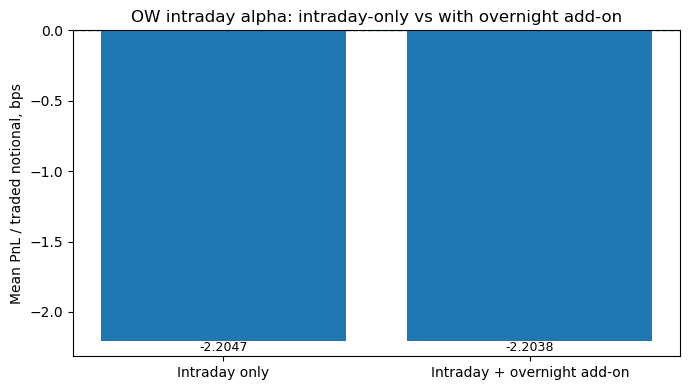

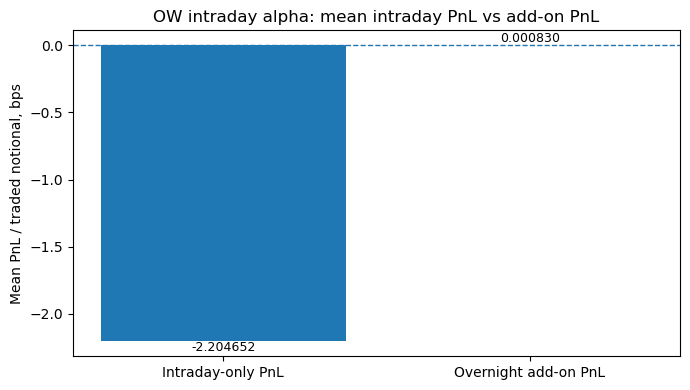

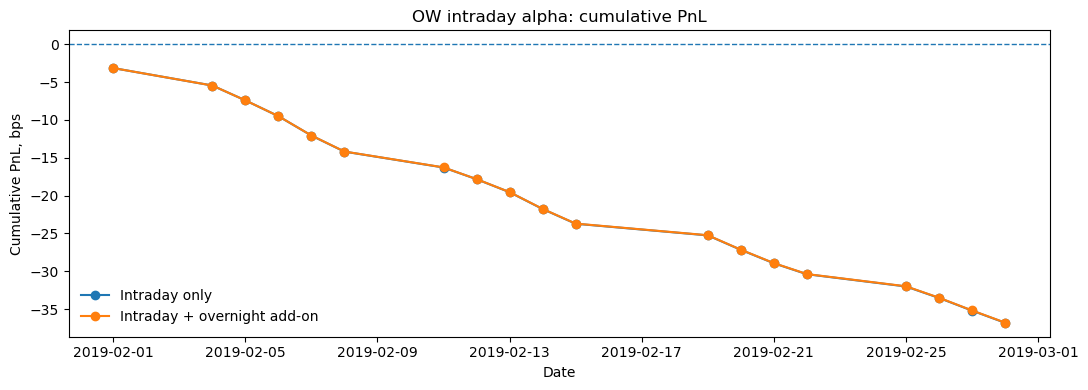

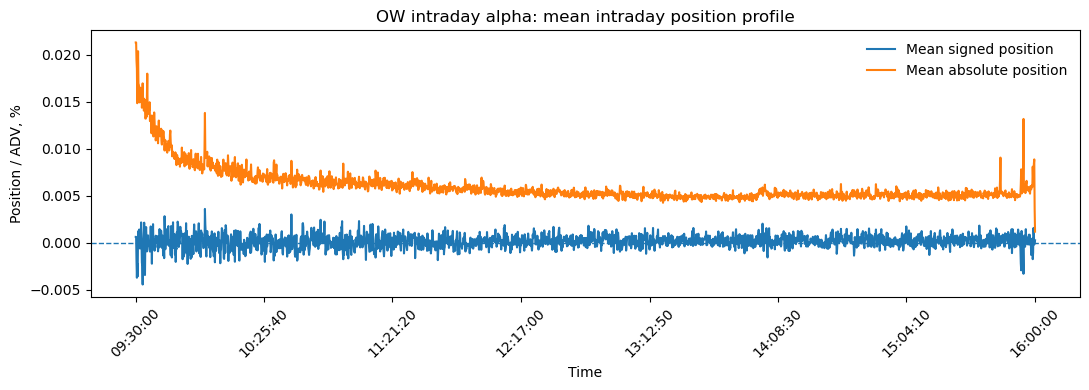

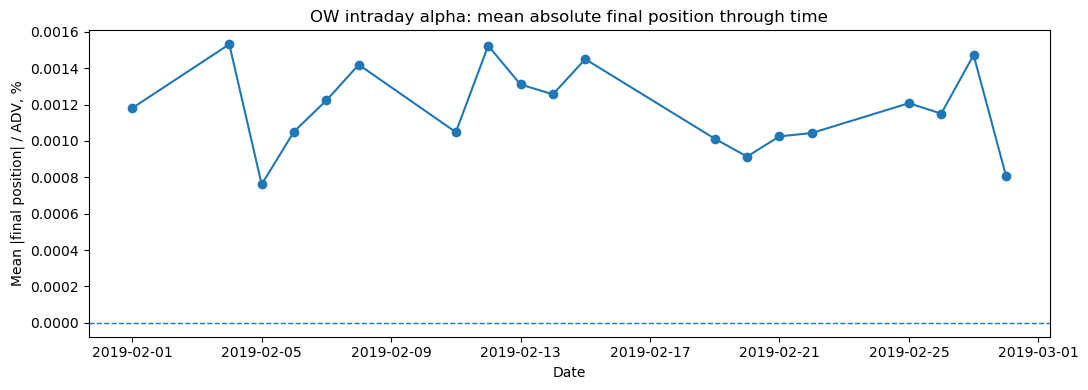

In [7]:
diagnostic_outputs = run_ow_overnight_addon_plots(
    overnight_addon_results_df=overnight_addon_results_df,
    ow_alpha_trades_df=ow_alpha_trades_df,
    scaling_df=scaling_df,
    strategy_name="OW intraday alpha",
)

### Theory outline for the rolling/carry version

The purpose of the rolling/carry version is to compare whether adding an overnight alpha improves the strategy relative to using only the intraday alpha.

We therefore build two alpha inputs.

#### A. Intraday-only alpha

The first strategy uses only the synthetic intraday alpha from Section 2.4:

$$
\alpha^A_{i,d,j} = \alpha^{intra}_{i,d,j}.
$$

#### B. Combined alpha

The second strategy adds an overnight alpha component:

$$
\alpha^B_{i,d,j}
=
\alpha^{intra}_{i,d,j}
+
\alpha^{ON}_{i,d,j}.
$$

The overnight alpha is computed once per stock-day as the next-open return:

$$
\alpha^{ON}_{i,d}
=
\frac{
P_{i,d+1,\text{open}} - P_{i,d,\text{close}}
}{
P_{i,d,\text{close}}
}.
$$

Since the existing intraday strategy function expects an alpha value at every intraday bin, we repeat the same overnight alpha across the bins of day $d$:

$$
\alpha^{ON}_{i,d,j}
=
\alpha^{ON}_{i,d}.
$$

Therefore, during day $d$, the combined-alpha strategy sees both the intraday signal and the constant overnight signal:

$$
\alpha^B_{i,d,j}
=
\alpha^{intra}_{i,d,j}
+
\alpha^{ON}_{i,d}.
$$

The comparison of interest is:

```text
rolling intraday-only alpha
vs
rolling combined alpha

### 2. Compute target impact from alpha

For each stock-day, we use the same OW lecture-note formula:

$$
I^*_{i,d,j}
=
\frac{1}{2}
\left(
\alpha_{i,d,j}
-
\frac{1}{\beta_i}
\alpha'_{i,d,j}
\right),
$$

with

$$
\beta_i
=
\frac{\log 2}{H_i},
$$

where $H_i$ is the fitted OW half-life for stock $i$.

Here, $\alpha_{i,d,j}$ is the alpha signal used by the strategy. Depending on the scenario, this may be the intraday-only alpha or the combined intraday-plus-overnight alpha.

The derivative $\alpha'_{i,d,j}$ measures how fast the alpha signal is changing through the day. In discrete time, it is approximated by

$$
\alpha'_{i,d,j}
\approx
\frac{
\alpha_{i,d,j} - \alpha_{i,d,j-1}
}{
\Delta t
}.
$$

We can reuse the existing function

```python
ow_target_impact_from_alpha

### 3. Recover trades with a carried impact state

This is the first function that needs to change for the rolling/carry version.

The old daily-reset version assumes that the impact state is reset to zero at the start of each day:

```python
prev_I = 0.0
```

inside

```python
recover_ow_trades_from_target_impact
```

This is fine for the daily-reset version, but not for the rolling/carry version.

In the rolling version, the initial impact state at the start of day $d$ may be non-zero:

$$
I^{initial}_{i,d,0} \neq 0.
$$

Therefore, the first trade of the day should account for the impact state already carried into the day:

$$
q_{i,d,0}
=
\frac{
I^*_{i,d,0}
-
e^{-\beta_i \Delta t} I^{initial}_{i,d,0}
}{
\lambda_i \sigma_i / ADV_i
}.
$$

For later intraday bins, the usual OW recovery formula is still used:

$$
q_{i,d,j}
=
\frac{
I^*_{i,d,j}
-
e^{-\beta_i \Delta t} I^*_{i,d,j-1}
}{
\lambda_i \sigma_i / ADV_i
}.
$$

So we need a new function such as:

```python
recover_ow_trades_from_target_impact_with_initial_state(...)
```

It should take:

```python
I_star
lambda_hat
ADV
sigma
half_life_seconds
initial_impact_state
dt_seconds
```

and return:

```python
trades
```

or, preferably:

```python
trades
raw_target_impact
```

This change allows the strategy to start each day from the impact state carried over from the previous day, instead of incorrectly assuming that impact always starts from zero.

### 4. Carry position, cash, and own impact

The current daily backtest computes position, cash, impact, and portfolio value inside one stock-day only. In `simulate_one_stock_day`, the position is just

```python
my_trades.cumsum()
```

and cash starts from zero every day.

The rolling/carry version needs to carry:

$$
Q_t, \quad K_t, \quad I_t.
$$

where:

- $Q_t$ is the current position,
- $K_t$ is the cash account,
- $I_t$ is the own impact state.

At the end of day $d$, we save:

```python
final_position
final_cash
final_impact_state
final_close_price
```

At the next open, we start with:

```python
initial_position = yesterday_final_position
initial_cash = yesterday_final_cash
initial_impact_state = decayed_yesterday_final_impact
```

The own impact state decays overnight:

$$
I_{d+1,\text{open}}
=
e^{-\beta \Delta t_{\text{overnight}}}
I_{d,\text{close}}.
$$

Then, during the intraday session, own impact evolves as:

$$
I_{d,j}
=
e^{-\beta \Delta t}
I_{d,j-1}
+
\lambda_i \sigma_i \frac{q_{d,j}}{ADV_i}.
$$

The position must also be updated from the carried initial position:

$$
Q_{d,j}
=
Q_{d,0}^{initial}
+
\sum_{k \leq j} q_{d,k}.
$$

Similarly, cash must start from the carried cash account:

$$
K_{d,j}
=
K_{d,0}^{initial}
-
\sum_{k \leq j} q_{d,k} P^{exec}_{d,k}.
$$

Therefore, the marked-to-market portfolio value is:

$$
V_{d,j}
=
K_{d,j}
+
Q_{d,j} P_{d,j}.
$$

This is the key difference from the daily-reset version: the rolling version does not restart the trading book from zero every morning.

### 5. Compute P&L decomposition

For each day, we decompose total P&L into overnight P&L and intraday P&L.

#### Overnight P&L

The overnight P&L for stock $i$ on day $d$ is

$$
\text{overnight P\&L}_{i,d}
=
Q_{i,d-1,\text{close}}
\left(
P_{i,d,\text{open}} - P_{i,d-1,\text{close}}
\right).
$$

For the first day, this value is zero because there is no previous closing position.

#### Intraday P&L

Let the portfolio value at the open of day $d$ be

$$
V_{d,\text{open}}
=
K_{d,\text{open}}
+
Q_{d,\text{open}} P_{d,\text{open}},
$$

and the portfolio value at the close be

$$
V_{d,\text{close}}
=
K_{d,\text{close}}
+
Q_{d,\text{close}} P_{d,\text{close}}.
$$

Then the intraday P&L is

$$
\text{intraday P\&L}_{i,d}
=
V_{d,\text{close}}
-
V_{d,\text{open}}.
$$

#### Total daily P&L

The total daily P&L is

$$
\text{total P\&L}_{i,d}
=
\text{overnight P\&L}_{i,d}
+
\text{intraday P\&L}_{i,d}.
$$

This is the correct accounting for the rolling strategy because it separates the return earned from carrying yesterday's position overnight from the return earned through intraday trading on day $d$.

### Visual summary: rolling/carry notebook functions

Create a new file:

```python
src/overnight_carry_backtest.py
```

Do **not** heavily modify the existing `.py` files. The rolling/carry logic is an extension, so it is cleaner to isolate it in a new module.

---

### 1. Functions you can reuse

| Function | From file | Use in rolling notebook? | Purpose |
|---|---|---|---|
| `align_intraday_columns` | `data_prep.py` | Yes | Make sure price, volume, intraday alpha, and overnight alpha have the same intraday time columns. |
| `get_best_model_fit_df` | `backtest_engine.py` | Yes | Extract OW fitted parameters: `lambda_hat` and `half_life_seconds`. |
| `make_impact_adjusted_prices` | `backtest_engine.py` | Yes | Remove public-market impact day by day, as before. |
| `make_next_open_overnight_alpha_panel` | `optimal_trading_strategies.py` | Yes | Build the repeated overnight alpha panel. |
| `ow_target_impact_from_alpha` | `optimal_trading_strategies.py` | Yes | Convert an alpha path into OW target impact $I_t^*$. |

These functions are safe to reuse.

### 2. Functions you should not reuse for rolling/carry

| Function | Why not? |
|---|---|
| `recover_ow_trades_from_target_impact` | Assumes each day starts with zero impact. |
| `make_ow_optimal_trade_df` | Builds trades independently stock-day by stock-day. It does not move sequentially through the month. |
| `simulate_one_stock_day` | Resets position, cash, and impact every day. |
| `run_backtest_from_trade_df` | Daily-reset engine. It is not a carry engine. |
| `run_strategy_backtests_for_model` | Wrapper around the daily-reset engine. |

These functions are still fine for the baseline 2.5 notebook, but they should not be used for the rolling/carry extension.

### 3. New functions to create

| New function | Purpose |
|---|---|
| `make_combined_alpha_df` | Build `combined_alpha_df = intraday_alpha_df + overnight_alpha_df`. |
| `recover_ow_trades_from_target_impact_with_initial_state` | Recover trades from $I_t^*$, allowing a non-zero carried impact state at the start of the day. |
| `compute_ow_realized_impact_path` | Compute the realized OW impact path from executed trades and the initial carried impact. |
| `compute_overnight_seconds` | Compute the close-to-next-open time gap used for overnight impact decay. |
| `simulate_one_stock_rolling_ow` | Core rolling function: simulate one stock across all dates while carrying position, cash, and own impact. |
| `run_rolling_ow_carry_backtest` | Loop over all stocks and collect paths/summaries. |
| `add_rolling_bps_metrics` | Add `intraday_pnl_bps`, `overnight_pnl_bps`, `total_pnl_bps`, and `impact_cost_bps`. |
```

## Important implementation caveats

### 1. Normalisation is less clean in the rolling backtest

> **Important interpretation**
>
> In the rolling/carry backtest, the strategy may begin day $d$ with an impact state already inherited from the previous day:
>
> $$
> I^{initial}_{i,d,0} \neq 0.
> $$
>
> Therefore, the realized impact path during day $d$ has two components:
>
> $$
> I^{realized}_{i,d,j}
> =
> \text{carried impact from previous days}
> +
> \text{impact created by today's trades}.
> $$
>
> The OW target impact path $I^*_{i,d,j}$ tells us where the strategy would like the impact state to be, given today's alpha signal. However, because the day starts with a nonzero carried impact state, the realized impact path may not perfectly match the target path.
>
> Visually, the comparison is:
>
> ```text
> previous day's impact
>          ↓
> carried initial impact
>          ↓
> today's trades
>          ↓
> realized impact path I_realized
>
> alpha signal
>          ↓
> target impact path I*
> ```
>
> So the useful diagnostic is the tracking gap:
>
> $$
> \text{impact tracking gap}_{i,d,j}
> =
> I^*_{i,d,j}
> -
> I^{realized}_{i,d,j}.
> $$
>
> If this gap is small, the executed strategy is closely following the OW target impact path.
>
> If this gap is large, the strategy is being pulled away from the target because of carried impact, trade normalisation, or both.
>
> In the first implementation, I will still normalise daily trading volume so that the intraday-only and combined-alpha strategies trade comparable amounts:
>
> $$
> \sum_j |q_{i,d,j}| = 0.20 ADV_i.
> $$
>
> However, because this normalisation can make the realized impact differ from the target impact, I should report the target-versus-realized impact gap as an additional diagnostic.

### Rolling/carry backtest pipeline

```text
Existing inputs
---------------
test_px_df
test_traded_volume_df
scaling_df
stock_results_df
best_df
synthetic_alpha_df


        │
        ▼


Step 1: Reuse existing helpers
------------------------------

get_best_model_fit_df
        │
        └──► ow_fit_df

make_next_open_overnight_alpha_panel
        │
        └──► overnight_alpha_df


        │
        ▼


Step 2: Build combined alpha
----------------------------

make_combined_alpha_df
        │
        └──► combined_alpha_df


        │
        ▼


Step 3: Run rolling OW carry backtest
-------------------------------------

run_rolling_ow_carry_backtest
        │
        └── simulate_one_stock_rolling_ow
                │
                ├── ow_target_impact_from_alpha
                │       existing
                │
                ├── recover_ow_trades_from_target_impact_with_initial_state
                │       new
                │
                ├── make_impact_adjusted_prices
                │       existing
                │
                └── compute_ow_realized_impact_path
                        new


        │
        ▼


Step 4: Backtest outputs
------------------------

rolling_path_df
rolling_summary_df


        │
        ▼


Step 5: Add performance metrics
-------------------------------

add_rolling_bps_metrics
```

The key change relative to the daily-reset backtest is that `simulate_one_stock_rolling_ow` processes each stock sequentially through time, carrying position, cash, and own impact from one day into the next.

In [8]:
# 1. Get OW fit.
ow_fit_df = get_best_model_fit_df(
    stock_results_df=stock_results_df,
    best_df=best_df,
    model_type="ow",
)

# 2. Build overnight alpha panel.
overnight_alpha_df, overnight_alpha_s = make_next_open_overnight_alpha_panel(
    test_px_df=test_px_df,
    overnight_alpha_level=1.0,
)

# 3. Build combined alpha.
combined_alpha_df = make_combined_alpha_df(
    intraday_alpha_df=synthetic_alpha_df,
    overnight_alpha_df=overnight_alpha_df,
    intraday_weight=1.0,
    overnight_weight=1.0,
)

# 4. Run rolling intraday-only strategy.
intraday_path_df, intraday_summary_df = run_rolling_ow_carry_backtest(
    alpha_df=synthetic_alpha_df,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    strategy_name="Rolling intraday alpha",
    dt_seconds=10,
    overnight_seconds=16 * 60 * 60,
    normalize_abs_volume=True,
    target_participation=0.20,
)

# 5. Run rolling combined-alpha strategy.
combined_path_df, combined_summary_df = run_rolling_ow_carry_backtest(
    alpha_df=combined_alpha_df,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    strategy_name="Rolling combined alpha",
    dt_seconds=10,
    overnight_seconds=16 * 60 * 60,
    normalize_abs_volume=True,
    target_participation=0.20,
)

# 6. Combine results.
rolling_path_df = pd.concat(
    [intraday_path_df, combined_path_df],
    ignore_index=True,
)

rolling_summary_df = pd.concat(
    [intraday_summary_df, combined_summary_df],
    ignore_index=True,
)

rolling_summary_df = add_rolling_bps_metrics(
    rolling_summary_df
)

In [9]:
print("rolling_path_df:", rolling_path_df.shape)
print("rolling_summary_df:", rolling_summary_df.shape)

print("\nStrategies:")
print(rolling_summary_df["strategy"].value_counts())

print("\nColumns:")
print(rolling_summary_df.columns.tolist())

print("\nMissing values in key columns:")
key_cols = [
    "intraday_pnl_bps",
    "overnight_pnl_bps",
    "total_pnl_bps",
    "impact_cost_bps",
    "final_position_over_ADV",
    "max_abs_position_over_ADV",
    "target_minus_realized_mean_abs",
    "target_minus_realized_max_abs",
]

print(rolling_summary_df[key_cols].isna().sum())

rolling_path_df: (1779160, 17)
rolling_summary_df: (760, 41)

Strategies:
strategy
Rolling intraday alpha    380
Rolling combined alpha    380
Name: count, dtype: int64

Columns:
['stock', 'date', 'overnight_pnl', 'intraday_pnl', 'total_pnl', 'impact_cost', 'start_position', 'final_position', 'max_abs_position', 'start_cash', 'final_cash', 'start_impact_state', 'final_impact_state', 'max_abs_impact_state', 'max_abs_impact_price', 'open_price', 'close_price', 'previous_close_price', 'raw_abs_volume', 'target_abs_volume', 'actual_abs_volume', 'scale_factor', 'total_abs_traded', 'net_traded', 'avg_price', 'traded_notional', 'ADV', 'sigma', 'lambda_hat', 'half_life_seconds', 'overnight_seconds', 'target_minus_realized_mean_abs', 'target_minus_realized_max_abs', 'strategy', 'intraday_pnl_bps', 'overnight_pnl_bps', 'total_pnl_bps', 'impact_cost_bps', 'final_position_over_ADV', 'start_position_over_ADV', 'max_abs_position_over_ADV']

Missing values in key columns:
intraday_pnl_bps            

In [10]:
rolling_summary_table = (
    rolling_summary_df
    .groupby("strategy")[[
        "intraday_pnl_bps",
        "overnight_pnl_bps",
        "total_pnl_bps",
        "impact_cost_bps",
        "final_position_over_ADV",
        "max_abs_position_over_ADV",
        "target_minus_realized_mean_abs",
        "target_minus_realized_max_abs",
    ]]
    .agg(["mean", "median", "std"])
    .round(6)
)

rolling_summary_table

intraday_pnl_bps                     overnight_pnl_bps  \
                                   mean    median       std              mean   
strategy                                                                        
Rolling combined alpha        -2.199595 -1.934637  0.974586          0.028667   
Rolling intraday alpha        -2.205370 -1.959879  1.010793          0.001725   

                                           total_pnl_bps                      \
                          median       std          mean    median       std   
strategy                                                                       
Rolling combined alpha  0.002058  0.208545     -2.170928 -1.923891  0.966302   
Rolling intraday alpha  0.000019  0.019097     -2.203645 -1.959665  1.011616   

                       impact_cost_bps  ... final_position_over_ADV  \
                                  mean  ...                     std   
strategy                                ...                           
Rolling combined alpha        0.100361  ...                0.000307   
Rolling intraday alpha        0.100355  ...                0.000045   

                       max_abs_position_over_ADV                      \
                                            mean    median       std   
strategy                                                               
Rolling combined alpha                  0.000893  0.000829  0.000331   
Rolling intraday alpha                  0.000742  0.000686  0.000269   

                       target_minus_realized_mean_abs                      \
                                                 mean    median       std   
strategy                                                                    
Rolling combined alpha                       0.024139  0.021646  0.007938   
Rolling intraday alpha                       0.023903  0.021462  0.007850   

                       target_minus_realized_max_abs                      
                                                mean    median       std  
strategy                                                                  
Rolling combined alpha                      0.292245  0.255944  0.143008  
Rolling intraday alpha                      0.292342  0.254897  0.142665  

[2 rows x 24 columns]

In [11]:
(
    rolling_summary_df
    .groupby("strategy")[[
        "intraday_pnl_bps",
        "overnight_pnl_bps",
        "total_pnl_bps",
        "impact_cost_bps",
        "max_abs_position_over_ADV",
    ]]
    .mean()
    .round(6)
)

,intraday_pnl_bps,overnight_pnl_bps,total_pnl_bps,impact_cost_bps,max_abs_position_over_ADV
strategy,,,,,
Rolling combined alpha,-2.199595,0.028667,-2.170928,0.100361,0.000893
Rolling intraday alpha,-2.205370,0.001725,-2.203645,0.100355,0.000742


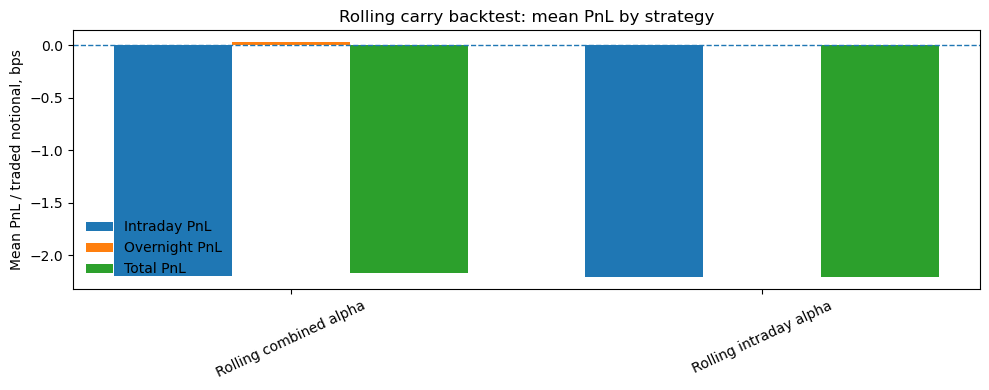

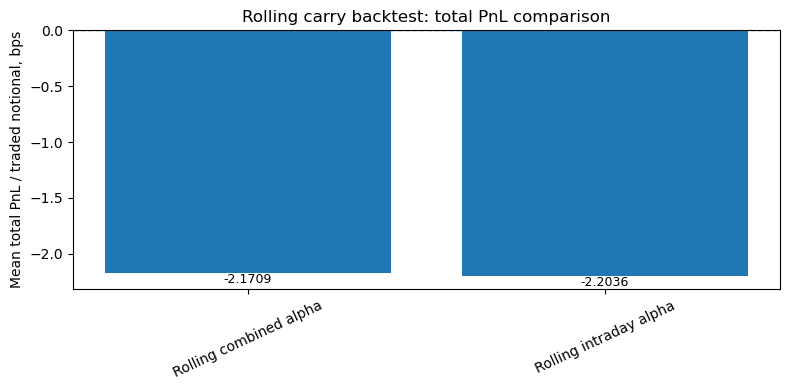

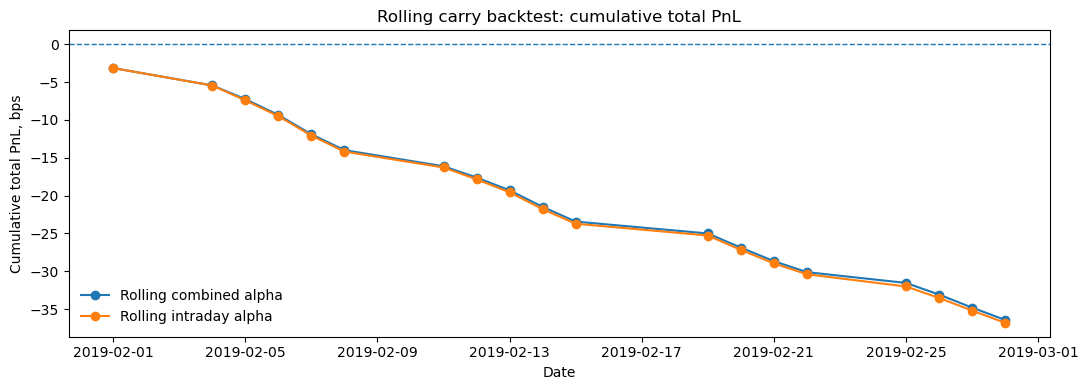

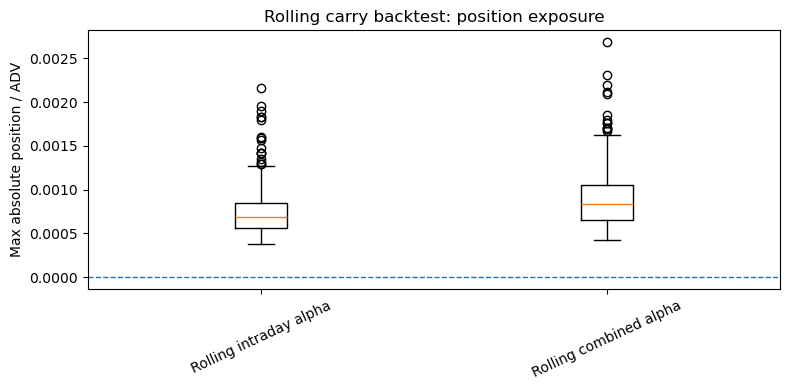

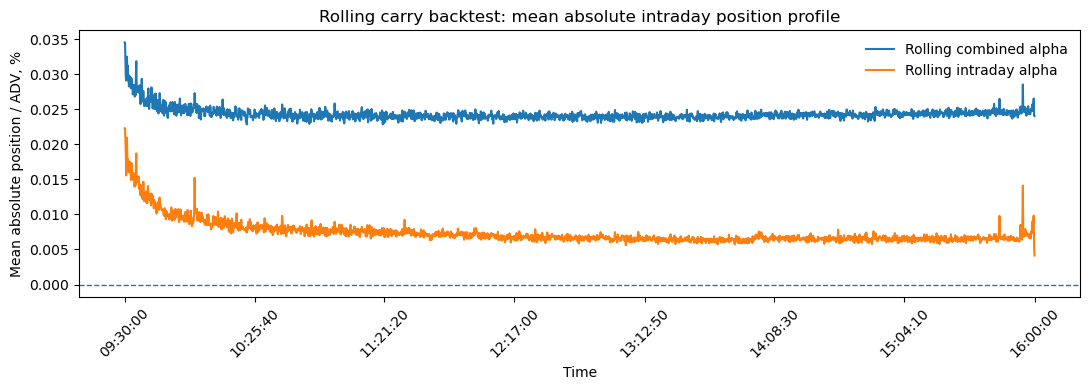

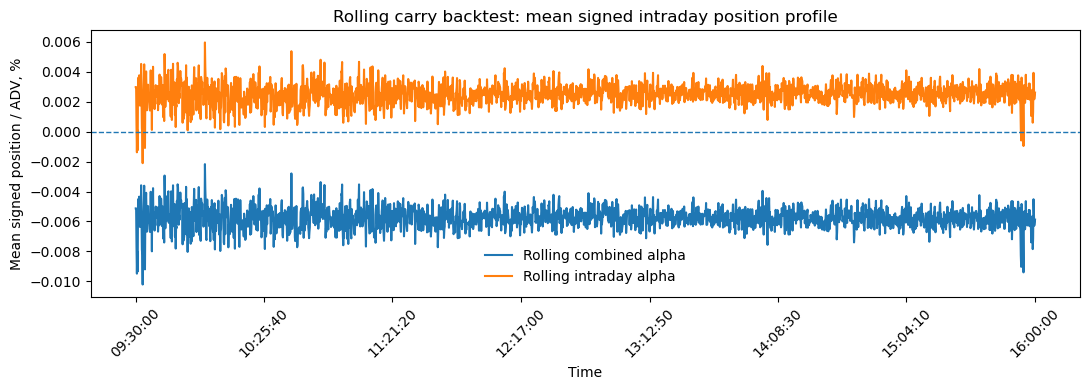

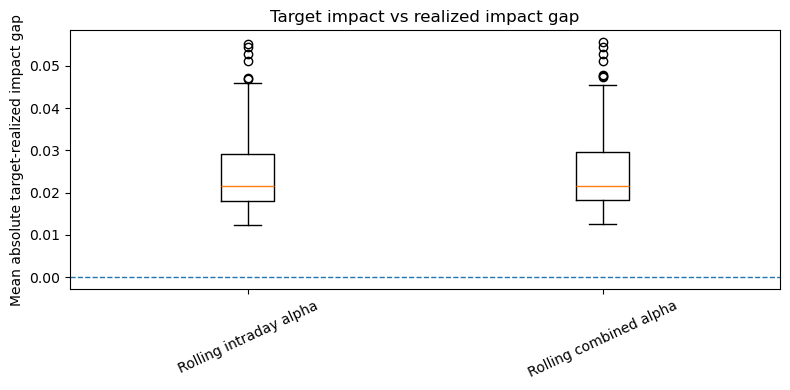

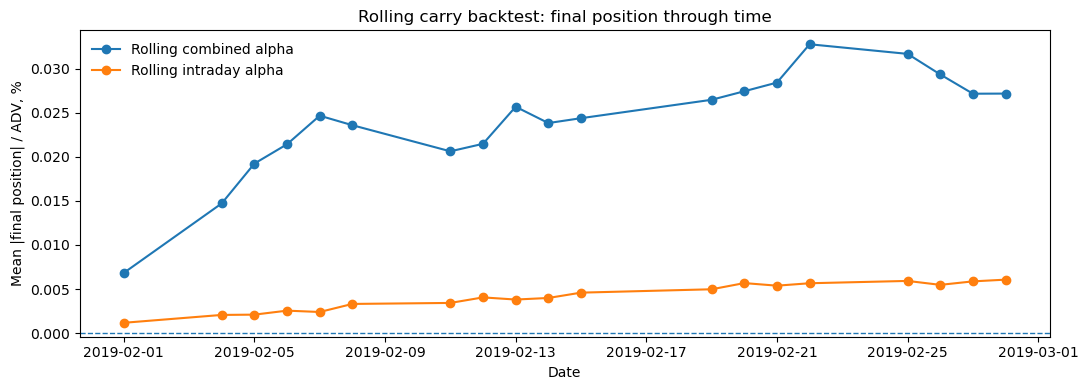

In [12]:
rolling_diagnostics = run_rolling_carry_diagnostic_plots(
    rolling_summary_df=rolling_summary_df,
    rolling_path_df=rolling_path_df,
    scaling_df=scaling_df,
)

## Overnight-weight sensitivity with fixed trading volume

Because the strategy is normalized to trade a fixed daily amount,

$$
\sum_j |q_{i,d,j}| = 0.20 ADV_i,
$$

scaling the entire alpha signal is not very informative. If we multiply all alpha values by a constant, the raw trades become larger, but the normalization rescales them back to the same total traded volume.

Instead, the useful test is to change the **relative weight** of the overnight component:

$$
\alpha^{combined}_{i,d,j}
=
\alpha^{intra}_{i,d,j}
+
w_{ON}\alpha^{ON}_{i,d,j}.
$$

Here, total traded volume stays fixed, but the strategy allocates more or less of its trading budget toward the overnight signal.

This means the test is not asking:

$$
\text{What happens when alpha is simply larger?}
$$

It is asking:

$$
\text{What happens when the same trading budget is tilted more toward overnight alpha?}
$$

For each value of $w_{ON}$, we should compare:

- overnight P&L;
- intraday P&L;
- impact cost;
- total P&L;
- final position;
- maximum position.

If increasing $w_{ON}$ mainly increases overnight P&L, then the overnight signal is contributing something distinct. If total P&L barely changes, then the strategy is not meaningfully exploiting the overnight component under the current constraints.

In [13]:
overnight_weights = [0.0, 1.0, 2.0, 5.0, 10.0]

weighted_path_df, weighted_summary_df = run_weighted_overnight_alpha_experiment(
    intraday_alpha_df=synthetic_alpha_df,
    overnight_alpha_df=overnight_alpha_df,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    overnight_weights=overnight_weights,
    dt_seconds=10,
    overnight_seconds=16 * 60 * 60,
    normalize_abs_volume=True,
    target_participation=0.20,
)

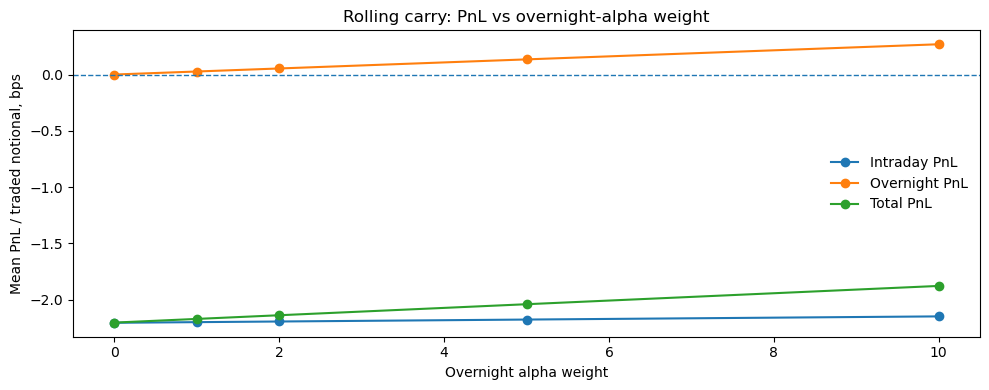

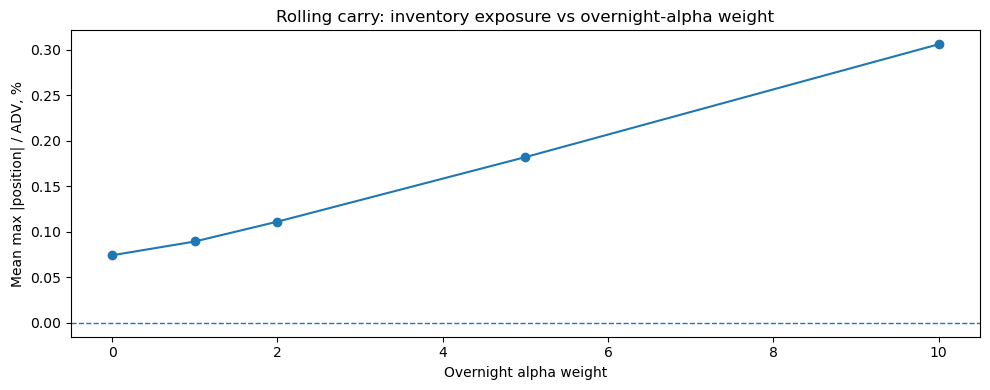

,overnight_weight,intraday_pnl_bps,overnight_pnl_bps,total_pnl_bps,impact_cost_bps,max_abs_position_over_ADV
0,0.0,-2.205370,0.001725,-2.203645,0.100355,0.000742
1,1.0,-2.199595,0.028667,-2.170928,0.100361,0.000893
2,2.0,-2.193827,0.055605,-2.138222,0.100379,0.001111
3,5.0,-2.176622,0.136379,-2.040243,0.100506,0.001820
4,10.0,-2.148404,0.270852,-1.877552,0.100980,0.003060


In [14]:
weighted_summary_plot_df = plot_weighted_overnight_experiment_summary(
    weighted_summary_df
)

weighted_summary_plot_df

$$
\text{target daily volume} = 0.2 \times ADV
$$

the actual rescaling applied to the raw trades is:

$$
\text{scale\_factor} = \frac{0.2 \times ADV}{\sum_t |q_t^{raw}|}
$$

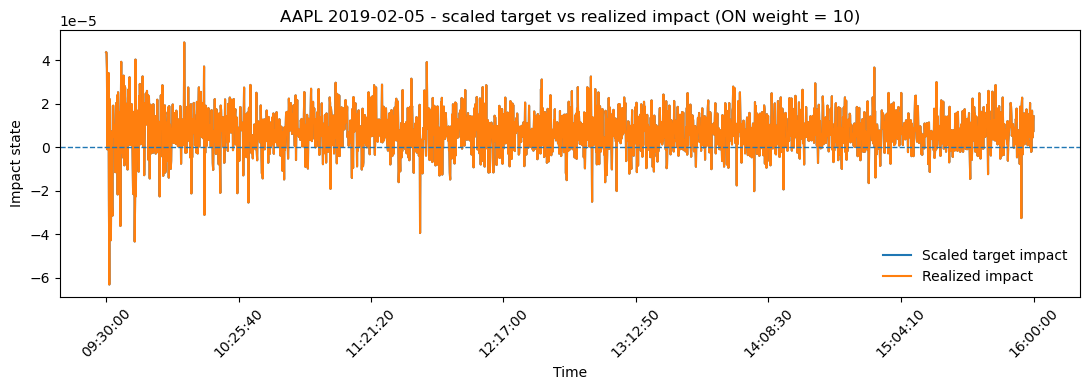

,stock,date,time,mid_price,raw_mid_price,alpha,alpha_prime,target_impact,trade,realized_impact,target_minus_realized,impact_in_price,execution_price,position,cash,portfolio_value,strategy,overnight_weight,scaled_target_impact
3607481,AAPL,2019-02-05,09:30:00,172.800012,172.835,0.040084,-8.018332e-05,0.124154,1107.954993,4.373875e-05,0.124110,0.007558,172.807570,8474.273907,-1.479000e+06,-14645.846911,Rolling alpha: intra + 10 x ON,10.0,4.373875e-05
3607482,AAPL,2019-02-05,09:30:10,172.882779,172.865,0.039282,-8.018332e-05,0.123753,0.680537,4.359751e-05,0.123710,0.007534,172.890312,8474.954444,-1.479118e+06,-13944.460390,Rolling alpha: intra + 10 x ON,10.0,4.359751e-05
3607483,AAPL,2019-02-05,09:30:20,172.748314,172.665,0.038643,-6.393474e-05,0.102336,-186.883519,3.605234e-05,0.102300,0.006230,172.754544,8288.070926,-1.446833e+06,-15082.881714,Rolling alpha: intra + 10 x ON,10.0,3.605234e-05
3607484,AAPL,2019-02-05,09:30:30,172.624201,172.540,0.038813,1.700323e-05,-0.002671,-933.574698,-9.409577e-07,-0.002670,-0.000163,172.624039,7354.496227,-1.285676e+06,-16111.687014,Rolling alpha: intra + 10 x ON,10.0,-9.409577e-07
3607485,AAPL,2019-02-05,09:30:40,172.679030,172.585,0.038292,-5.209665e-05,0.086790,798.257061,3.057546e-05,0.086759,0.005283,172.684314,8152.753289,-1.423522e+06,-15712.664752,Rolling alpha: intra + 10 x ON,10.0,3.057546e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3609817,AAPL,2019-02-05,15:59:20,173.986204,174.075,0.040589,-2.123924e-05,0.047872,450.065605,1.686507e-05,0.047855,0.002914,173.989119,9416.492961,-1.661632e+06,-23292.419338,Rolling alpha: intra + 10 x ON,10.0,1.686507e-05
3609818,AAPL,2019-02-05,15:59:30,174.015159,174.085,0.040648,5.912425e-06,0.012647,-312.705639,4.455567e-06,0.012643,0.000770,174.015929,9103.787322,-1.607217e+06,-23019.529226,Rolling alpha: intra + 10 x ON,10.0,4.455567e-06
3609819,AAPL,2019-02-05,15:59:40,174.090090,174.090,0.040500,-1.485515e-05,0.039538,240.408675,1.392906e-05,0.039524,0.002407,174.092497,9344.195997,-1.649070e+06,-22337.948778,Rolling alpha: intra + 10 x ON,10.0,1.392906e-05
3609820,AAPL,2019-02-05,15:59:50,174.085999,174.050,0.040500,-1.120629e-09,0.020251,-170.760313,7.134417e-06,0.020244,0.001233,174.087232,9173.435684,-1.619343e+06,-22375.963953,Rolling alpha: intra + 10 x ON,10.0,7.134417e-06


In [15]:
plot_scaled_target_vs_realized_impact_one_day(
    weighted_path_df=weighted_path_df,
    weighted_summary_df=weighted_summary_df,
    stock="AAPL",
    date="2019-02-05",
    overnight_weight=10.0,
)

### Interpretation of the weighted overnight-alpha sensitivity

The important pattern is:

$$
w_{ON} \uparrow
\quad \Rightarrow \quad
\text{overnight P\&L} \uparrow
\quad \Rightarrow \quad
\text{total P\&L improves}.
$$

At $w_{ON} = 10$, total P\&L is still negative:

$$
-1.88 \text{ bps}.
$$

So this is a meaningful improvement, but not a full solution.

---

### Why this is a useful result

This result is stronger than the previous add-on test because the strategy is now actually changing its exposure. The position diagnostic shows:

$$
w_{ON} \uparrow
\quad \Rightarrow \quad
\max |Q| / ADV \uparrow.
$$

So the strategy is allocating more of its trading budget toward overnight positioning. That is exactly what this test was designed to check.

Also, impact cost stays almost flat:

$$
\text{impact cost} \approx 0.100 \text{ bps}.
$$

This happens because total daily traded volume is still normalised. Therefore, the performance improvement is not coming from simply trading more volume. It is coming from changing the composition, timing, and direction of the trades.

---

### What this suggests

The overnight alpha is directionally useful in the synthetic setup.

However, it is still weak relative to the intraday losses. At $w_{ON} = 10$, the overnight P\&L is only:

$$
0.27 \text{ bps},
$$

while intraday P\&L remains around:

$$
-2.15 \text{ bps}.
$$

So the overnight component helps, but it is not large enough to dominate the negative intraday component.

### Additional robustness test: shuffled overnight alpha

A useful robustness check is to shuffle the overnight alpha across dates or stocks, and then rerun the same overnight-weight sensitivity experiment.

The comparison is:

```text
true overnight alpha
vs
shuffled overnight alpha
```

The logic is:

$$
\text{true overnight alpha improves P\&L}
\quad \text{but} \quad
\text{shuffled overnight alpha does not}
$$

then the improvement is much more likely to be coming from the information in the overnight signal, rather than from simply adding more overnight exposure.

In other words, the test separates:

$$
\text{benefit from directional overnight information}
$$

from

$$
\text{benefit from mechanically holding larger overnight positions}.
$$


In [16]:
overnight_weights = [0.0, 1.0, 2.0, 5.0, 10.0]

true_weighted_path_df, true_weighted_summary_df = run_weighted_overnight_alpha_experiment(
    intraday_alpha_df=synthetic_alpha_df,
    overnight_alpha_df=overnight_alpha_df,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    overnight_weights=overnight_weights,
    dt_seconds=10,
    overnight_seconds=16 * 60 * 60,
    normalize_abs_volume=True,
    target_participation=0.20,
)

true_weighted_summary_df["overnight_alpha_type"] = "True overnight alpha"

In [17]:
shuffled_overnight_alpha_df = make_shuffled_overnight_alpha_df(
    overnight_alpha_df=overnight_alpha_df,
    random_seed=1234,
)

shuffled_weighted_path_df, shuffled_weighted_summary_df = run_weighted_overnight_alpha_experiment(
    intraday_alpha_df=synthetic_alpha_df,
    overnight_alpha_df=shuffled_overnight_alpha_df,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    overnight_weights=overnight_weights,
    dt_seconds=10,
    overnight_seconds=16 * 60 * 60,
    normalize_abs_volume=True,
    target_participation=0.20,
)

shuffled_weighted_summary_df["overnight_alpha_type"] = "Shuffled overnight alpha"

In [18]:
placebo_comparison_summary_df = pd.concat(
    [
        true_weighted_summary_df,
        shuffled_weighted_summary_df,
    ],
    ignore_index=True,
)

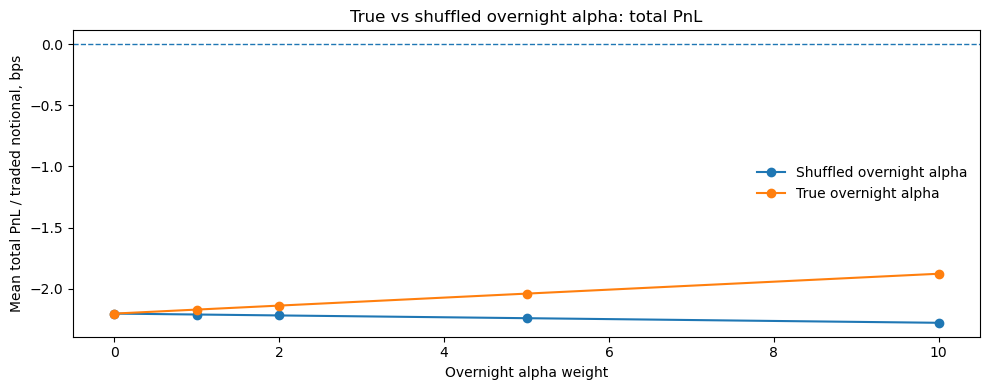

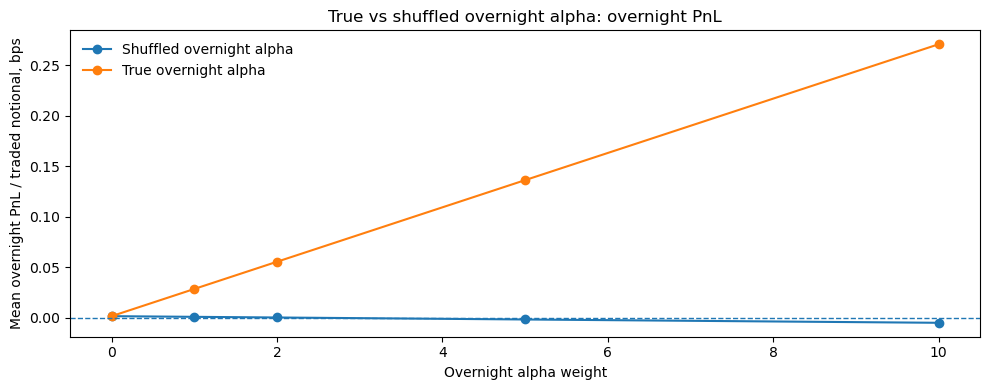

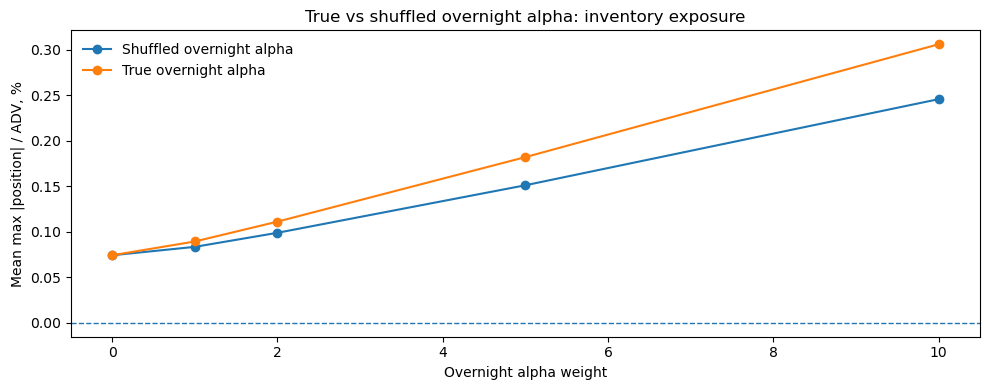

,overnight_alpha_type,overnight_weight,intraday_pnl_bps,overnight_pnl_bps,total_pnl_bps,impact_cost_bps,max_abs_position_over_ADV
0,Shuffled overnight alpha,0.0,-2.205370,0.001725,-2.203645,0.100355,0.000742
1,Shuffled overnight alpha,1.0,-2.212259,0.001068,-2.211191,0.100360,0.000834
2,Shuffled overnight alpha,2.0,-2.219132,0.000412,-2.218721,0.100377,0.000989
3,Shuffled overnight alpha,5.0,-2.239733,-0.001555,-2.241288,0.100500,0.001511
4,Shuffled overnight alpha,10.0,-2.274128,-0.004836,-2.278964,0.100964,0.002457
5,True overnight alpha,0.0,-2.205370,0.001725,-2.203645,0.100355,0.000742
6,True overnight alpha,1.0,-2.199595,0.028667,-2.170928,0.100361,0.000893
7,True overnight alpha,2.0,-2.193827,0.055605,-2.138222,0.100379,0.001111
8,True overnight alpha,5.0,-2.176622,0.136379,-2.040243,0.100506,0.001820
9,True overnight alpha,10.0,-2.148404,0.270852,-1.877552,0.100980,0.003060


In [19]:
placebo_plot_df = plot_true_vs_shuffled_overnight_alpha_experiment(
    placebo_comparison_summary_df
)

placebo_plot_df

So the evidence is:

$$
\text{more overnight exposure alone}
\neq
\text{better P\&L},
$$

whereas

$$
\text{more exposure guided by the true overnight alpha}
\Rightarrow
\text{better overnight P\&L}.
$$

### Overnight-only rolling strategy

As a final comparison, I run a rolling OW strategy using only the overnight alpha.  
This removes the intraday synthetic alpha from the combined signal and allows us to isolate the effect of the overnight component.

The strategy is generated using the same rolling/carry backtest engine as before.  
To reuse the existing weighted-alpha function, I set the intraday alpha panel to zero and use an overnight weight equal to one:
$$
\alpha_t = \alpha_t^{ON}
$$

The daily absolute traded volume is still normalized to \(0.2 \times ADV\), so the comparison remains on the same turnover scale as the previous strategies.

In [20]:
# Build a zero intraday alpha panel.
zero_intraday_alpha_df = synthetic_alpha_df * 0.0

# Run overnight-only strategy.
overnight_only_path_df, overnight_only_summary_df = run_weighted_overnight_alpha_experiment(
    intraday_alpha_df=zero_intraday_alpha_df,
    overnight_alpha_df=overnight_alpha_df,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    overnight_weights=[1.0],
    dt_seconds=10,
    overnight_seconds=16 * 60 * 60,
    normalize_abs_volume=True,
    target_participation=0.20,
)

# Rename strategy for clearer plots/tables.
overnight_only_path_df["strategy"] = "Rolling overnight alpha only"
overnight_only_summary_df["strategy"] = "Rolling overnight alpha only"

In [21]:
overnight_only_summary_df[
    [
        "intraday_pnl_bps",
        "overnight_pnl_bps",
        "total_pnl_bps",
        "impact_cost_bps",
        "max_abs_position_over_ADV",
    ]
].mean()

intraday_pnl_bps            -42.679042
overnight_pnl_bps            37.320757
total_pnl_bps                -5.358285
impact_cost_bps              36.226600
max_abs_position_over_ADV     0.502579
dtype: float64

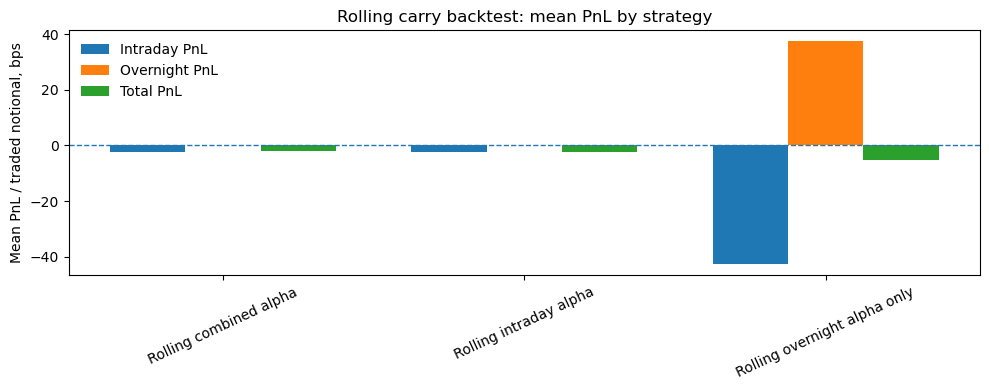

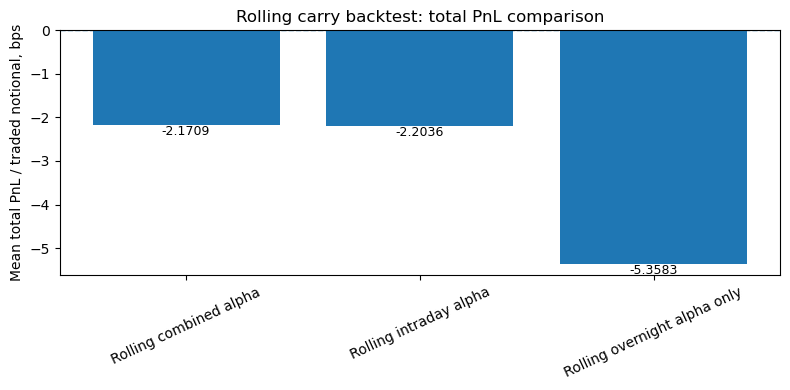

strategy
Rolling combined alpha         -2.170928
Rolling intraday alpha         -2.203645
Rolling overnight alpha only   -5.358285
Name: total_pnl_bps, dtype: float64

In [22]:
rolling_comparison_summary_df = pd.concat(
    [
        rolling_summary_df,
        overnight_only_summary_df,
    ],
    ignore_index=True,
)

plot_rolling_mean_pnl_by_strategy(rolling_comparison_summary_df)
plot_rolling_total_pnl_comparison(rolling_comparison_summary_df)